# Credit Risk Intelligence Platform
## Notebook 1 — Data Loading, SQL Schema & EDA

**Dataset:** Credit Risk Dataset (Laotse, Kaggle) — 32,581 borrowers



In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('./data',    exist_ok=True)
os.makedirs('./outputs', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2d3154',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#2d3154',
    'grid.linewidth':   0.5,
    'font.family':      'DejaVu Sans',
})
ACCENT = '#7c6af7'
RED    = '#ef4444'
GREEN  = '#10b981'
YELLOW = '#f59e0b'
BLUE   = '#56b4e9'

print("  Imports done")

  Imports done


In [2]:
import os
print(os.getcwd())

c:\Users\gsure\Desktop\credit_risk_Intelligence_platform\notebooks


In [3]:
df = pd.read_csv('../data/raw/credit_risk_dataset.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 3 rows:\n{df.head(3)}")
print(f"\nDefault rate: {df['loan_status'].mean()*100:.1f}%")

Shape: (32581, 12)

Columns:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Data types:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

First 3 rows:
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25       

## Data Cleaning

Key issues to fix:
- Missing values in `person_emp_length` and `loan_int_rate`
- Outliers in `person_age` (some ages > 100 — data entry errors)
- Outliers in `person_emp_length` (> 60 years employment)
- Ensure correct data types throughout

In [4]:
print("Before cleaning:")
print(f"  Shape: {df.shape}")
print(f"  Nulls:\n{df.isnull().sum()[df.isnull().sum()>0]}")

# ── Remove impossible ages ────────────────────────────────────
df = df[df['person_age'] <= 80].copy()

# ── Remove impossible employment lengths ─────────────────────
df = df[df['person_emp_length'] <= 60].copy()

# ── Fill missing employment length with median ────────────────
df['person_emp_length'] = df['person_emp_length'].fillna(
    df['person_emp_length'].median()
)

# ── Fill missing interest rate with median per grade ─────────
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'].transform(
    lambda x: x.fillna(x.median())
)

# ── Create borrower_id ────────────────────────────────────────
df['borrower_id'] = range(1, len(df) + 1)

# ── Derived columns ───────────────────────────────────────────
df['debt_to_income']    = df['loan_amnt'] / (df['person_income'] + 1)
df['loan_to_income']    = df['loan_amnt'] / (df['person_income'] + 1)
df['income_per_year']   = df['person_income']
df['monthly_payment']   = (df['loan_amnt'] * 
                           (df['loan_int_rate']/100/12)) / (
                           1 - (1 + df['loan_int_rate']/100/12) ** 
                           (-df['loan_term_months'] if 
                            'loan_term_months' in df.columns else -36)
                           ) if 'loan_term_months' in df.columns else (
                           df['loan_amnt'] / 36)

print(f"\nAfter cleaning:")
print(f"  Shape: {df.shape}")
print(f"  Nulls: {df.isnull().sum().sum()}")
print(f"  Default rate: {df['loan_status'].mean()*100:.1f}%")
print("\n Cleaning done")

Before cleaning:
  Shape: (32581, 12)
  Nulls:
person_emp_length     895
loan_int_rate        3116
dtype: int64

After cleaning:
  Shape: (31677, 17)
  Nulls: 0
  Default rate: 21.5%

 Cleaning done


## SQL Schema — 4 Table Design

Splitting into 4 tables mirrors how a real bank database works:
- `borrowers` — who the person is
- `loans` — what they borrowed
- `credit_profile` — their credit history
- `default_labels` — ground truth + later predictions

In [5]:
conn = sqlite3.connect('./data/credit_risk.db')

# Table 1 — borrowers (demographic info)
df[['borrower_id',
    'person_age',
    'person_income',
    'person_home_ownership',
    'person_emp_length']].to_sql(
    'borrowers', conn,
    if_exists='replace', index=False)

# Table 2 — loans (loan details)
df[['borrower_id',
    'loan_intent',
    'loan_grade',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'debt_to_income']].to_sql(
    'loans', conn,
    if_exists='replace', index=False)

# Table 3 — credit profile (credit history)
df[['borrower_id',
    'cb_person_default_on_file',
    'cb_person_cred_hist_length']].to_sql(
    'credit_profile', conn,
    if_exists='replace', index=False)

# Table 4 — default labels (ground truth)
df[['borrower_id',
    'loan_status']].to_sql(
    'default_labels', conn,
    if_exists='replace', index=False)

print(" 4 tables written to ./data/credit_risk.db")

# Verify
for table in ['borrowers','loans','credit_profile','default_labels']:
    count = pd.read_sql(
        f"SELECT COUNT(*) as n FROM {table}", conn
    ).iloc[0,0]
    print(f"   {table}: {count:,} rows")

 4 tables written to ./data/credit_risk.db
   borrowers: 31,677 rows
   loans: 31,677 rows
   credit_profile: 31,677 rows
   default_labels: 31,677 rows


In [6]:
queries = {

"default_by_intent": """
    SELECT l.loan_intent,
           COUNT(*)                          AS total_loans,
           SUM(d.loan_status)                AS defaults,
           ROUND(AVG(d.loan_status)*100, 1)  AS default_rate_pct,
           ROUND(AVG(l.loan_int_rate), 2)    AS avg_interest_rate,
           ROUND(AVG(l.loan_amnt), 0)        AS avg_loan_amount
    FROM loans l
    JOIN default_labels d ON l.borrower_id = d.borrower_id
    GROUP BY l.loan_intent
    ORDER BY default_rate_pct DESC
""",

"default_by_grade": """
    SELECT l.loan_grade,
           COUNT(*)                          AS total_loans,
           SUM(d.loan_status)                AS defaults,
           ROUND(AVG(d.loan_status)*100, 1)  AS default_rate_pct,
           ROUND(AVG(l.loan_int_rate), 2)    AS avg_interest_rate
    FROM loans l
    JOIN default_labels d ON l.borrower_id = d.borrower_id
    GROUP BY l.loan_grade
    ORDER BY l.loan_grade
""",

"default_by_home_ownership": """
    SELECT b.person_home_ownership,
           COUNT(*)                          AS total_borrowers,
           SUM(d.loan_status)                AS defaults,
           ROUND(AVG(d.loan_status)*100, 1)  AS default_rate_pct,
           ROUND(AVG(b.person_income), 0)    AS avg_income,
           ROUND(AVG(b.person_age), 1)       AS avg_age
    FROM borrowers b
    JOIN default_labels d ON b.borrower_id = d.borrower_id
    GROUP BY b.person_home_ownership
    ORDER BY default_rate_pct DESC
""",

"high_risk_profile": """
    SELECT
        CASE
            WHEN b.person_age < 25 THEN 'Under 25'
            WHEN b.person_age < 35 THEN '25-34'
            WHEN b.person_age < 45 THEN '35-44'
            WHEN b.person_age < 55 THEN '45-54'
            ELSE '55+'
        END AS age_group,
        ROUND(AVG(d.loan_status)*100, 1)     AS default_rate_pct,
        COUNT(*)                             AS total,
        ROUND(AVG(l.loan_amnt), 0)           AS avg_loan_amount,
        ROUND(AVG(b.person_income), 0)       AS avg_income
    FROM borrowers b
    JOIN loans l         ON b.borrower_id = l.borrower_id
    JOIN default_labels d ON b.borrower_id = d.borrower_id
    GROUP BY age_group
    ORDER BY default_rate_pct DESC
""",

"credit_history_vs_default": """
    SELECT
        CASE
            WHEN cp.cb_person_cred_hist_length <= 2  THEN '0-2 years'
            WHEN cp.cb_person_cred_hist_length <= 5  THEN '3-5 years'
            WHEN cp.cb_person_cred_hist_length <= 10 THEN '6-10 years'
            ELSE '10+ years'
        END AS credit_history_bucket,
        cp.cb_person_default_on_file         AS prior_default,
        COUNT(*)                             AS total,
        ROUND(AVG(d.loan_status)*100, 1)     AS default_rate_pct
    FROM credit_profile cp
    JOIN default_labels d ON cp.borrower_id = d.borrower_id
    GROUP BY credit_history_bucket, prior_default
    ORDER BY default_rate_pct DESC
"""
}

sql_results = {}
for name, q in queries.items():
    result = pd.read_sql(q, conn)
    result.to_csv(f'./data/{name}.csv', index=False)
    sql_results[name] = result
    print(f"\n── {name} ──")
    print(result.to_string(index=False))

conn.close()
print("\n  All SQL queries done — CSVs saved in ./data/")


── default_by_intent ──
      loan_intent  total_loans  defaults  default_rate_pct  avg_interest_rate  avg_loan_amount
DEBTCONSOLIDATION         5064      1437              28.4              11.05           9670.0
          MEDICAL         5896      1565              26.5              11.06           9352.0
  HOMEIMPROVEMENT         3510       897              25.6              11.24          10449.0
         PERSONAL         5366      1046              19.5              11.01           9644.0
        EDUCATION         6288      1066              17.0              11.00           9521.0
          VENTURE         5553       814              14.7              10.97           9653.0

── default_by_grade ──
loan_grade  total_loans  defaults  default_rate_pct  avg_interest_rate
         A        10369       991               9.6               7.36
         B        10183      1622              15.9              11.00
         C         6318      1283              20.3              13.46
  

## EDA Visualisations

6 plots that tell the full borrower story:
1. Default rate by loan intent
2. Default rate by loan grade
3. Age distribution — defaulters vs non-defaulters
4. Income distribution — defaulters vs non-defaulters
5. Interest rate vs default rate
6. Correlation heatmap

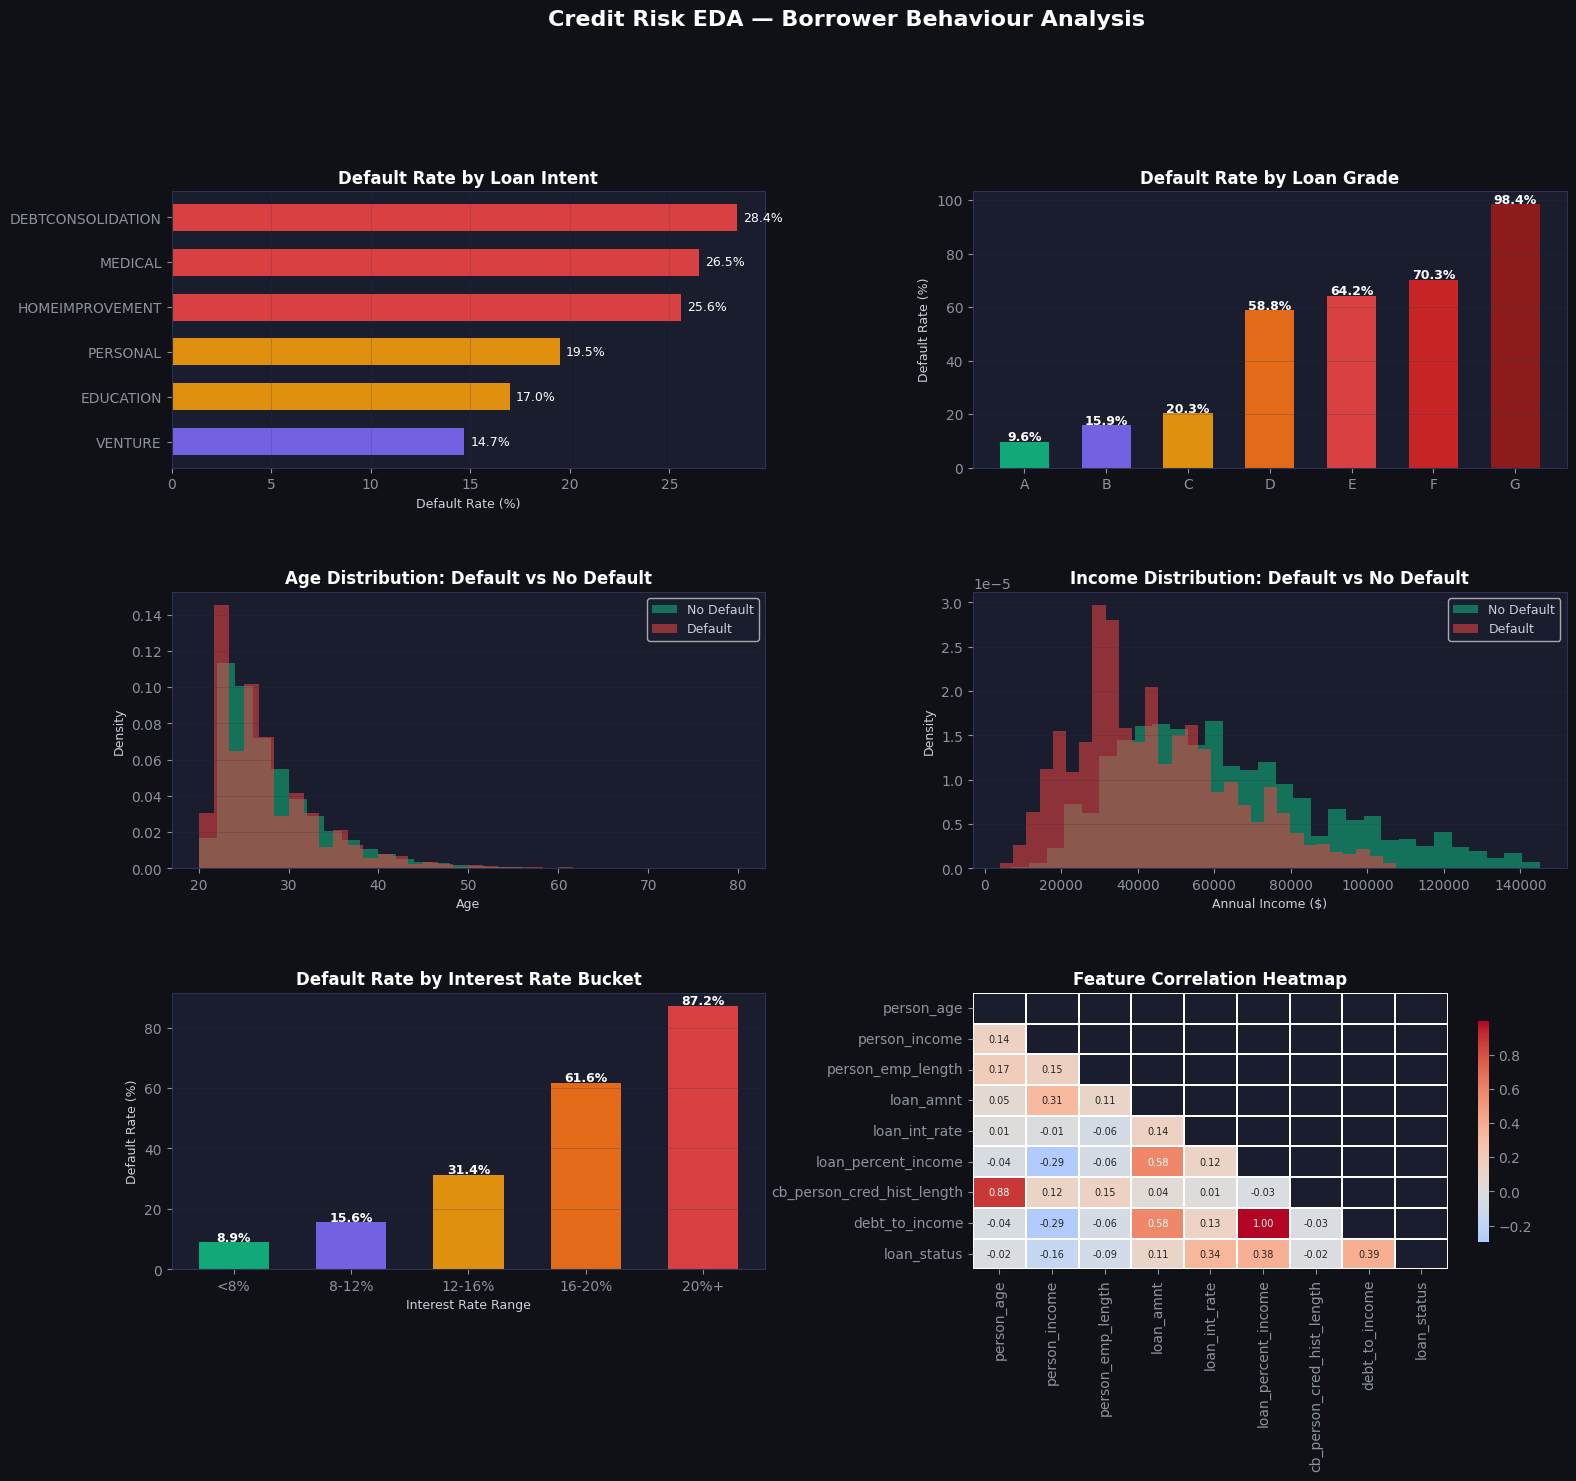

 Saved: ./outputs/eda_overview.png


In [7]:
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0f1117')
gs  = gridspec.GridSpec(3, 2, figure=fig,
                        hspace=0.45, wspace=0.35)

# ── Plot 1: Default rate by loan intent ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#1a1d2e')
intent = sql_results['default_by_intent'].sort_values(
    'default_rate_pct', ascending=True)
colors = [RED if r > 20 else YELLOW if r > 15
          else ACCENT for r in intent['default_rate_pct']]
bars = ax1.barh(intent['loan_intent'],
                intent['default_rate_pct'],
                color=colors, alpha=0.9, height=0.6)
for bar, val in zip(bars, intent['default_rate_pct']):
    ax1.text(bar.get_width() + 0.3,
             bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=9, color='white')
ax1.set_title('Default Rate by Loan Intent',
              fontsize=12, fontweight='bold', color='white')
ax1.set_xlabel('Default Rate (%)', fontsize=9)
ax1.grid(axis='x', alpha=0.3)

# ── Plot 2: Default rate by grade ────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#1a1d2e')
grade = sql_results['default_by_grade']
grade_colors = [GREEN, ACCENT, YELLOW,
                '#f97316', RED, '#dc2626', '#991b1b'][:len(grade)]
bars2 = ax2.bar(grade['loan_grade'],
                grade['default_rate_pct'],
                color=grade_colors, alpha=0.9, width=0.6)
for bar, val in zip(bars2, grade['default_rate_pct']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=9,
             color='white', fontweight='bold')
ax2.set_title('Default Rate by Loan Grade',
              fontsize=12, fontweight='bold', color='white')
ax2.set_ylabel('Default Rate (%)', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# ── Plot 3: Age distribution ─────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('#1a1d2e')
for status, color, label in [(0, GREEN, 'No Default'),
                              (1, RED,   'Default')]:
    vals = df[df['loan_status']==status]['person_age']
    ax3.hist(vals, bins=30, alpha=0.55,
             color=color, label=label, density=True)
ax3.set_title('Age Distribution: Default vs No Default',
              fontsize=12, fontweight='bold', color='white')
ax3.set_xlabel('Age', fontsize=9)
ax3.set_ylabel('Density', fontsize=9)
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# ── Plot 4: Income distribution ──────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('#1a1d2e')
for status, color, label in [(0, GREEN, 'No Default'),
                              (1, RED,   'Default')]:
    vals = df[df['loan_status']==status]['person_income']
    vals = vals[vals < vals.quantile(0.95)]  # remove extreme outliers
    ax4.hist(vals, bins=30, alpha=0.55,
             color=color, label=label, density=True)
ax4.set_title('Income Distribution: Default vs No Default',
              fontsize=12, fontweight='bold', color='white')
ax4.set_xlabel('Annual Income ($)', fontsize=9)
ax4.set_ylabel('Density', fontsize=9)
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)

# ── Plot 5: Interest rate vs default ─────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
ax5.set_facecolor('#1a1d2e')
df['rate_bucket'] = pd.cut(df['loan_int_rate'],
                           bins=[0,8,12,16,20,30],
                           labels=['<8%','8-12%',
                                   '12-16%','16-20%','20%+'])
rate_default = df.groupby('rate_bucket',
                          observed=True)['loan_status'].mean()*100
bars5 = ax5.bar(rate_default.index,
                rate_default.values,
                color=[GREEN, ACCENT, YELLOW,
                       '#f97316', RED][:len(rate_default)],
                alpha=0.9, width=0.6)
for bar, val in zip(bars5, rate_default.values):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center',
             fontsize=9, color='white', fontweight='bold')
ax5.set_title('Default Rate by Interest Rate Bucket',
              fontsize=12, fontweight='bold', color='white')
ax5.set_ylabel('Default Rate (%)', fontsize=9)
ax5.set_xlabel('Interest Rate Range', fontsize=9)
ax5.grid(axis='y', alpha=0.3)

# ── Plot 6: Correlation heatmap ───────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
ax6.set_facecolor('#1a1d2e')
num_cols = ['person_age','person_income','person_emp_length',
            'loan_amnt','loan_int_rate','loan_percent_income',
            'cb_person_cred_hist_length','debt_to_income',
            'loan_status']
corr = df[[c for c in num_cols
           if c in df.columns]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax6, mask=mask,
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.3,
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
ax6.set_title('Feature Correlation Heatmap',
              fontsize=12, fontweight='bold', color='white')

fig.suptitle('Credit Risk EDA — Borrower Behaviour Analysis',
             fontsize=16, fontweight='bold',
             color='white', y=1.01)

plt.savefig('./outputs/eda_overview.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(" Saved: ./outputs/eda_overview.png")

In [9]:
df.to_csv('./data/df_cleaned.csv', index=False)

print(" Saved: ./data/df_cleaned.csv")
print(f"\n  Key findings to note for your resume:")
print(f"    Default rate overall: {df['loan_status'].mean()*100:.1f}%")
print(f"    Highest risk intent:  {sql_results['default_by_intent'].iloc[0]['loan_intent']}")
print(f"    Highest risk grade:   {sql_results['default_by_grade'].iloc[-1]['loan_grade']}")
print(f"    Total borrowers:      {len(df):,}")


 Saved: ./data/df_cleaned.csv

  Key findings to note for your resume:
    Default rate overall: 21.5%
    Highest risk intent:  DEBTCONSOLIDATION
    Highest risk grade:   G
    Total borrowers:      31,677
